Análisis exploratorio inicial de la base, caracterizando sus atributos y describiendo su comportamiento, distribución de variables, presencia de outliers, valores nulos y demás particularidades que crea de relevancia para el análisis.

long: Longitud geográfica (X coordinate) donde se encuentra el árbol.
lat: Latitud geográfica (Y coordinate) donde se encuentra el árbol.
nro_registro: Número de registro único del árbol en el sistema.
tipo_activ 	string 	Tipo de actividad o clasificación del árbol (e.g., 'Lineal').
comuna 	string 	Número de la comuna donde se encuentra el árbol.
manzana 	string 	Identificador de la manzana donde se encuentra el árbol.
calle_nombre 	string 	Nombre de la calle donde se encuentra ubicado el árbol.
calle_altura 	string 	Altura de la calle donde se encuentra el árbol.
calle_chapa 	string 	Número de chapa de la calle más cercano al árbol.
direccion_normalizada 	string 	Dirección normalizada para la ubicación del árbol (e.g., 'ESMERALDA 1120').
ubicacion 	string 	Información adicional sobre la ubicación del árbol (e.g., 'Exacta').
nombre_cientifico 	string 	Nombre científico de la especie del árbol.
ancho_acera 	string 	Ancho de la acera donde está ubicado el árbol, en metros.
estado_plantera 	string 	Estado de la plantación (e.g., 'Ocupada').
ubicacion_plantera 	string 	Condición de la ubicación de la plantación (e.g., 'Regular').
nivel_plantera 	string 	Nivel de la plantación respecto al suelo (e.g., 'A nivel, Elevada').
diametro_altura_pecho 	string 	Diámetro del árbol a la altura del pecho, en centímetros.
altura_arbol 	string 	Altura del árbol en metros.

long: Cuantitativa continua
lat: cuantitativa continua
nro_registro: Cualitativo nominal
tipo_activ: Cualitativo nominal
comuna: Cualitativo nominal
manzana: Cualitativo nominal
calle_nombre: Cualitativo nominal
calle_altura: Cuantitativo discreto
calle_chapa: cuantitativo discreto
direccion_normalizada: Cualitativo nominal
ubicacion: Cualitativo nominal
nombre_cientifico: Cualitativo nominal
ancho_acera: Cuantitativo  continuo
estado_plantera: Cualitativo nominal
ubicacion_plantera: Cualitativo nominal
nivel_plantera: Cualitativo nominal
diametro_altura_pecho: Cuantitativo continuo
altura_arbol: Cuantitativo continuo

In [33]:

from wget import download
from os import path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#abrimos el archivo de base de datos
if not path.exists("arbolado-publico-lineal-2017-2018.csv"):
  download("https://cdn.buenosaires.gob.ar/datosabiertos/datasets/atencion-ciudadana/arbolado-publico-lineal/arbolado-publico-lineal-2017-2018.csv")
else:
  print("El archivo ya existe")

dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")

#dataset.info()
#dataset.head()
#dataset.describe()
dataset["calle_nombre"].value_counts()
filas_nan = dataset[dataset[["lat","manzana","calle_nombre"]].isna().all(axis=1)]
#print(filas_nan[["comuna", "calle_altura", "lat", "manzana","calle_chapa"]])
cantidad_por_comuna = filas_nan['comuna'].value_counts()

print(cantidad_por_comuna)

El archivo ya existe


/tmp/ipykernel_4426/1290889323.py:14: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")


comuna
12    1
Name: count, dtype: int64


LIMPIEZA

tipo_activ: Pasamos todo a minuculas y quitamos los espacios en blanco de la palabra Lineal 
// cuando saber si usamos 0 y 1 para una variable? se podria usar aca?
que hacemos con calle?
Decidimos eliminar esta columna. No nos aporta nada relevante para las hipotesis que planteamos y tampoco los valores son variables. Tenemos la mayoria de las muestras LINEAL y la otra opcion (CALLE) ni siquiera sabemos que significa

manzana: Reconoce el tipo como string y signos, simbolos, etc.
// que hacemos con los nulos?? y las letras NO habia que borrarlas todavia, que hacemos con estas?
capaz pueden ser manzanas repetidas(revisarlo con lat y long)

calle_altura: Busco si no hay valores decimales, al no encontrar paso los datos a int64 q acepta nulos? o reemplazo los nulos con algo, por ej con 0?
//que hacemos con los nulos aca tmb?

calle_chapa: aca pasa lo mismo que con la var anterior

direccion_normalizada: pasamos todo a minuscula y sacamos los espacios en blanco, comas y simbolos
//ver que hacer con los datos, separamos calle y altura en columnas distintas?

ubicacion: pasamos todo a minusculas. 
//tenemos que cambiar todo lo que no sea exacta por no exacta? o que hacemos?

nombre_cientifico: pasamos todo a minuscula, nada mas para limpiar

estado_plantera: paso a minusculas y borro las palabras que estan demas.
//que hacemos con las que tienen dos cosas? hacemos dos columnas? una para saber si esta ocupada y otra para saber si esta cerrada

ubicacion_plantera: paso a minusculas, agrego las letras que faltan
//que hacemos con las que tieen mas de una cosa?

nivel_plantera: paso a minusculas, elimino espacios y agrupo valores como EL,elevadas,elevado,... por elevada. cambio los strings "nan" y "obs" por NaN de pandas
//que hacemos con ochava???

diametro_altura_pecho: no modificamos nada. todos los que no son enteros son NaN
//habria que cambiarlo? (como para eliminar el .0 que es innecesario si son todos enteros o nulos)

altura_arbol: lo mismo que diametro_altura_pecho

In [34]:
copiaDataset= dataset

copiaDataset=copiaDataset.drop(columns=["tipo_activ"])

copiaDataset["manzana"] = copiaDataset["manzana"].astype(str).str.strip().str.lower()
copiaDataset["manzana"] = copiaDataset["manzana"].str.replace(r'[^a-z0-9]', '',  regex=True)
copiaDataset["manzana"].value_counts()

copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].astype(str).str.strip().str.lower()
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].str.replace(r'[^a-z ]', '',  regex=True)
#copiaDataset["calle_nombre"].value_counts()

copiaDataset["calle_altura"] = pd.to_numeric(copiaDataset["calle_altura"], errors='coerce')#conierto la col en numerica, todo en float y si no en NaN
(copiaDataset["calle_altura"] % 1 != 0).any()#veo si hay valores decimales
#copiaDataset['calle_altura'] = copiaDataset['calle_altura'].astype(float).astype('Int64') 
copiaDataset["calle_altura"] = (copiaDataset["calle_altura"].fillna(0).astype(float).astype(int))
#copiaDataset["calle_altura"].value_counts()

copiaDataset["direccion_normalizada"] = (copiaDataset["direccion_normalizada"].astype(str).str.strip().str.lower())
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r',', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'[^a-z0-9áéíóúñ ]', '', regex=True)
# Extraer altura (último número de la cadena)
copiaDataset["altura"] = copiaDataset["direccion_normalizada"].str.extract(r'(\d+)$')
# Quitar la altura de la dirección para quedarte con el nombre limpio
copiaDataset["calle"] = copiaDataset["direccion_normalizada"].str.replace(r'\s*\d+\s*$', '', regex=True)
#copiaDataset["direccion_normalizada"].value_counts()
#copiaDataset[['direccion_normalizada', 'calle', 'altura']].head(10)

copiaDataset["ubicacion"] = copiaDataset["ubicacion"].astype(str).str.strip().str.lower()
#copiaDataset["ubicacion"].value_counts()

copiaDataset["nombre_cientifico"] = copiaDataset["nombre_cientifico"].astype(str).str.strip().str.lower()
#copiaDataset["nombre_cientifico"].value_counts()

copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].astype(str).str.strip().str.lower()
#borro la palabra cantero
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('cantero ', '', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('ocupado', 'ocupada', regex=False)

copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["estado_plantera"].value_counts()

copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].astype(str).str.strip().str.lower()
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["elevadas","eleveda","el","elevado"],"elevada")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["bn","bajo bivel","baja nivel","reducida"],"bajo nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["an","regular"],"a nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["nan","obs: no tiene plantera definida"],np.nan)
#copiaDataset["nivel_plantera"].value_counts()
#copiaDataset["nivel_plantera"].isna().sum()

# Filtrar solo los valores que no son enteros y mostrar solo la columna
no_enteros = copiaDataset.loc[copiaDataset["diametro_altura_pecho"] % 1 != 0, "diametro_altura_pecho"]
#print(no_enteros)
#copiaDataset["diametro_altura_pecho"].isna().sum()

#print(copiaDataset.loc[copiaDataset["altura_arbol"] % 1 != 0, "altura_arbol"])
#copiaDataset["altura_arbol"].isna().sum()


ANALISIS UNIVARIADO

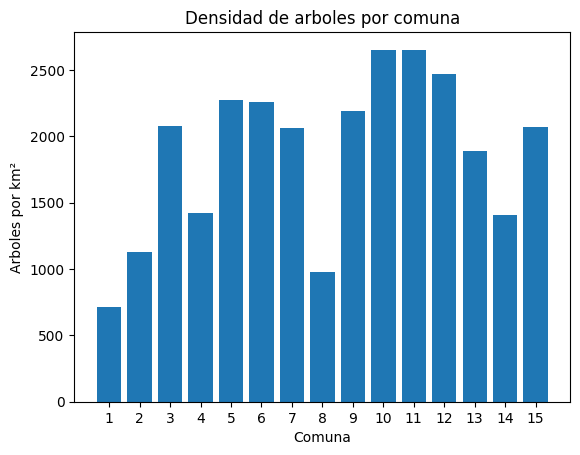

In [35]:
#Las comunas del norte de la Ciudad de Buenos Aires (como la 12, 13 y 14) 
# presentan mayor densidad de árboles por superficie urbana que las comunas del sur (4, 8 y 9).

superficies = { #en km²
    1: 17.9,  2: 6.3,  3: 6.4,  4: 22.7,  5: 6.7,
    6: 6.9,  7: 12.4, 8: 22.5, 9: 16.6, 10: 12.6,
    11: 14.1, 12: 15.7, 13: 15.0, 14: 15.9, 15: 14.3
}

datasetH1 = copiaDataset[["comuna"]].copy()

# 1️⃣ Contar cantidad de árboles por comuna
arboles_por_comuna = datasetH1.groupby("comuna").size().reset_index(name="cantidad_arboles")

# 2️⃣ Agregar la superficie de cada comuna
arboles_por_comuna["superficie"] = arboles_por_comuna["comuna"].map(superficies)

# 3️⃣ Calcular densidad de árboles por km²
arboles_por_comuna["densidad_arboles"] = arboles_por_comuna["cantidad_arboles"] / arboles_por_comuna["superficie"]

# graficamos el histograma
plt.bar(arboles_por_comuna["comuna"], arboles_por_comuna["densidad_arboles"])
plt.xticks(range(1,16))  
plt.xlabel("Comuna")
plt.ylabel("Arboles por km²")
plt.title("Densidad de arboles por comuna")
plt.show()


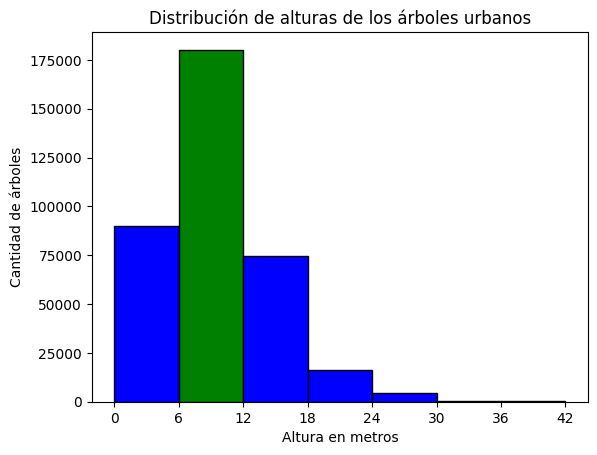

In [36]:
#La mayoría de los árboles tienen una altura media entre 6 y 12 metros, 
# correspondiente a especies medianas.

n, bins, barras = plt.hist(copiaDataset["altura_arbol"], bins=[0, 6, 12, 18, 24, 30, 36, 42], edgecolor="black")

# Cambiar el color de la barra correspondiente al intervalo 6–12
for i in range(len(barras)):
    if bins[i] == 6:  # este es el inicio del intervalo 6–12
        barras[i].set_facecolor("green") 
    else:
        barras[i].set_facecolor("blue") 

# Etiquetas en el eje X 
plt.xticks([0, 6, 12, 18, 24, 30, 36, 42])
plt.xlabel("Altura en metros")
plt.ylabel("Cantidad de árboles")
plt.title("Distribución de alturas de los árboles urbanos")
plt.show()

In [37]:
#El ancho de acera (mediana) disponible para el arbolado urbano es inferior a 2.5 metros.

datasetH3 = copiaDataset[["ancho_acera"]].copy()

# Hipótesis: el ancho de acera disponible es inferior a 2.5 m
datasetH3["hipotesis_menor_2_5"] = datasetH3["ancho_acera"] < 2.5

# Cantidad de aceras que cumplen la hipótesis
cantidad = df["hipotesis_menor_2_5"].sum()

# Calcular la mediana
mediana = datasetH3["ancho_acera"].median()

# Histograma
plt.figure(figsize=(8,5))
plt.hist(datasetH3["ancho_acera"], bins=20, color='skyblue', edgecolor='black')
plt.axvline(mediana, color='red', linestyle='dashed', linewidth=2, label=f'Mediana = {mediana:.2f} m')
plt.axvline(2.5, color='green', linestyle='dotted', linewidth=2, label='Umbral = 2.5 m')

plt.title('Distribución del ancho de acera')
plt.xlabel('Ancho de acera (m)')
plt.ylabel('Cantidad')
plt.legend()
plt.show()

TypeError: '<' not supported between instances of 'str' and 'float'

ANALISIS BIVARIADO

Existe una relación positiva significativa entre la altura del arbol y su cercania al Rio de la Plata.

Formas de plantear la distancia: 
1. tomamos un punto de referencia del rio (ej a la altura de caba)
2. tomamos diferentes puntos a lo largo del rio (da valores mas reales)

Elegimos la opcion 2.
Para elegir estos puntos tenemos en cuenta las comunas que limitan al rio (1,2,4,13 y 14) y elegimos un punto de la costa del rio aleatorio de cada una de ellas.
Comuna 1. Puerto Madero (34°36'25.1"S 58°20'44.9"W)
Comuna 2. Recoleta (34°34'30.2"S 58°23'15.0"W)
Comuna 13. Belgrano (34°32'51.6"S 58°25'50.0"W)
Comuna 14. Palermo (34°33'23.9"S 58°24'37.0"W)

long y lat: Vemos que hay muchos nulos y que no se encuentran en comunas especificas. 
Por lo tanto vamos a cambiarles los valores por: la combinacion de calle_nombre y calle_altura o el numero de manzana
Segun wikipedia:
Comuna 1.  (34°36′00″S 58°23′13″O)
Comuna 2. (34°35′26″S 58°23′26″O)
Comuna 3. (34°36′10″S 58°23′48″O)
Comuna 4. (34°39′01″S 58°25′28″O)
Comuna 5. (34°37′23″S 58°24′45″O)
Comuna 6. (34°37′00″S 58°27′00″O)
Comuna 7. (34°37′49″S 58°28′02″O)
Comuna 8. (34°41′09″S 58°27′20″O)
Comuna 9. (34°39′00″S 58°29′00″O)
Comuna 10. (34°37′55″S 58°29′01″O)
Comuna 11. (34°36′32″S 58°30′59″O)
Comuna 12. (34°34′07″S 58°28′58″O)
Comuna 13. (34°33′13″S 58°27′50″O)
Comuna 14. (34°35′20″S 58°25′50″O)
Comuna 15. (34°35′14″S 58°26′28″O)

In [ ]:
from shapely.geometry import Point,LineString
import geopandas as gpd

copiaDataset.loc[copiaDataset["long"].isna(), "comuna"].unique()



lat_map = {
    1 : -34.36,
    2 : -34.35,
    3 : -34.36,
    4 : -34.39,
    5 : -34.37,
    6 : -34.37,
    7 : -34.37,
    8 : -34.41,
    9 : -34.39,
    10 : -34.37,
    11 : -34.36,
    12 : -34.34,
    13 : -34.33,
    14 : -34.35,
    15 : -34.35,
}
long_map = {
    1 : -58.23,
    2 : -58.23,
    3 : -58.23,
    4 : -58.25,
    5 : -58.24,
    6 : -58.27,
    7 : -58.28,
    8 : -58.27,
    9 : -58.29,
    10 : -58.29,
    11 : -58.30,
    12 : -58.28,
    13 : -58.27,
    14 : -58.25,
    15 : -58.26,
}

#usamos copiaDataset u otro nuevo?
#Crea una columna virtual que tiene el valor de latitud correspondiente a la comuna de cada fila
#Despues toma la columna virtual como valor para lat
copiaDataset["lat"] = copiaDataset["lat"].fillna(copiaDataset["comuna"].map(lat_map))
copiaDataset["long"] = copiaDataset["long"].fillna(copiaDataset["comuna"].map(long_map))

#ya hicimos el preprocesamiento, ahora el analisis de las distancias

coords = [
    (-34.36,-58.20), #Puerto Madero
    (-34.34,-58.23), #Recoleta
    (-34.32,-58.25), #Belgrano
    (-34.33,-58.24), #Palermo
]

datasetH4 = copiaDataset[["altura_arbol","lat","long"]].copy()

# Transformamos la lista de (lat, long) a (long, lat) para Shapely/Geopandas
coords_rio_shapely = [(lon, lat) for lat, lon in coords]

# 1. Crear el GeoDataFrame de tus Puntos (Árboles)
#Crea el contenedor(datasetH4), le dice a GeoPandas cuáles columnas(long y lat) representan la ubicación de cada fila.
#Le dice a la computadora el sistema de coordenadas que estás usando.
puntos = gpd.GeoDataFrame(
    datasetH4, 
    geometry=gpd.points_from_xy(datasetH4.long, datasetH4.lat),
    crs="EPSG:4326"
)
#2. Crea la Línea del Río (LineString) a partir de los 4 puntos
linea_rio = LineString(coords_rio_shapely)

# Proyectamos todo a EPSG:32721 (UTM zone 21S), que usa el metro.
CRS_METROS = "EPSG:32721"

# 1. Proyecta los puntos del dataset a metros
gdf_puntos_metros = puntos.to_crs(CRS_METROS)
# 2. Proyecta la línea del río a metros
linea_rio_metros = linea_rio.to_crs(CRS_METROS)


# 1. Aplicamos .distance() sobre los objetos proyectados.
# La sintaxis de GeoPandas con una sola geometría requiere envolverla en un GeoSeries
gds_linea_metros = gpd.GeoSeries([linea_rio_metros])

distancias_en_metros = gdf_puntos_metros.distance(gds_linea_metros.iloc[0])

# 2. Asignar el resultado al DataFrame original
datasetH4['distancia_rio_metros'] = distancias_en_metros

print(datasetH4)


                                  id   gid  entidad             objeto  \
0  lineas_de_zona_costera_BA040.3042  3042        2  Accidente costero   
1  lineas_de_zona_costera_BA040.3043  3043        2  Accidente costero   
2  lineas_de_zona_costera_BA040.3044  3044        2  Accidente costero   
3  lineas_de_zona_costera_BA040.3045  3045        2  Accidente costero   
4  lineas_de_zona_costera_BA040.3046  3046        2  Accidente costero   

             fna    gna      nam  ta1  fdc  sag  \
0    Punta Norte  Punta    Norte   11  SHN  IGN   
1  Punta Entrada  Punta  Entrada   11  SHN  IGN   
2  Punta Cascajo  Punta  Cascajo   11  SHN  IGN   
3    Punta Norte  Punta    Norte   11  SHN  IGN   
4     Punta Ojos  Punta     Ojos   11  SHN  IGN   

                                            geometry  
0  MULTILINESTRING ((-69.12718 -50.8966, -69.0122...  
1  MULTILINESTRING ((-68.37158 -50.13915, -68.243...  
2  MULTILINESTRING ((-68.33613 -50.12592, -68.225...  
3  MULTILINESTRING ((-68.227

DataSourceError: limite_caba.geojson: No such file or directory